Number of communities: 4

Total number of nodes (colleges): 31

Community 0: ['10', '19', '30', '21', '26', '7', '29']
Community 1: ['4', '5', '6', '8']
Community 2: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 3: ['0', '1', '2', '3', '23', '22', '24']

Modularity: 0.4086261924803591
Coverage: 0.5789473684210527
Performance: 0.7935483870967742


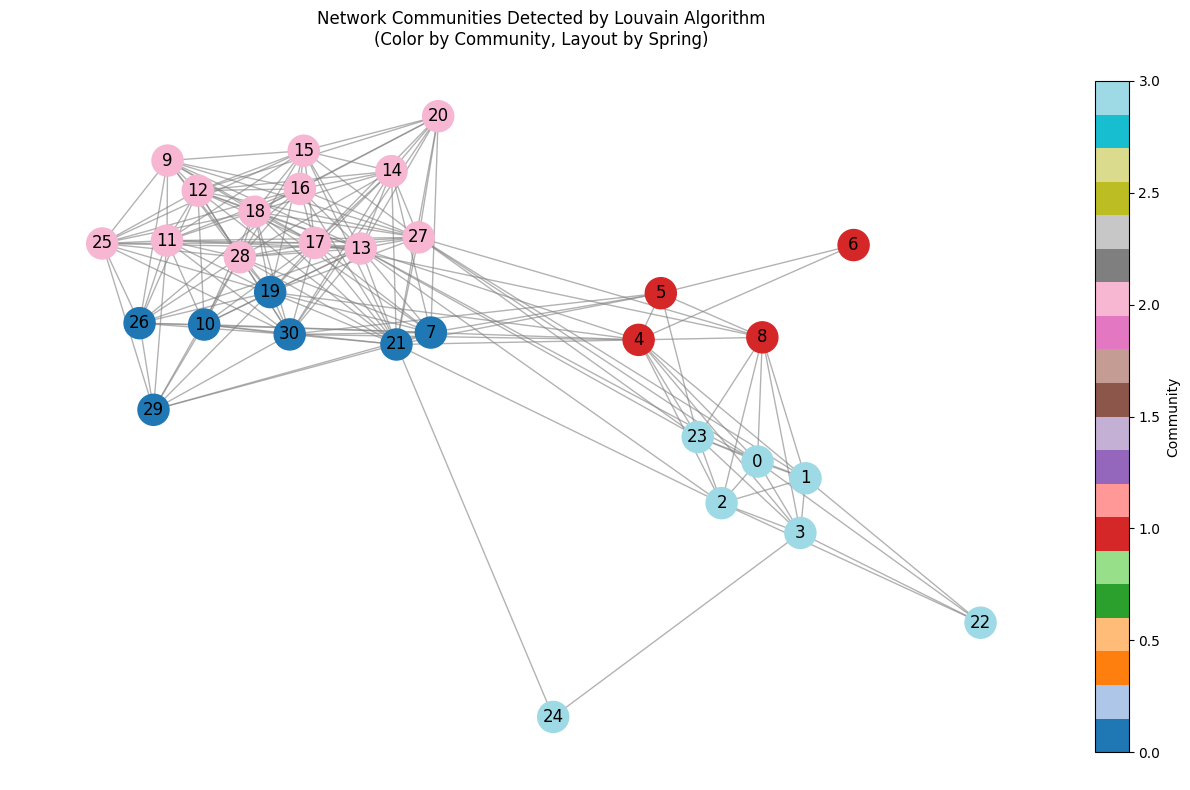

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses1.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 4

Total number of nodes (colleges): 30

Community 0: ['4', '5', '6', '8']
Community 1: ['10', '19', '30', '21', '26', '7', '29']
Community 2: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 3: ['0', '1', '2', '3', '23', '22']

Modularity: 0.45006638991483777
Coverage: 0.7377049180327869
Performance: 0.8574712643678161


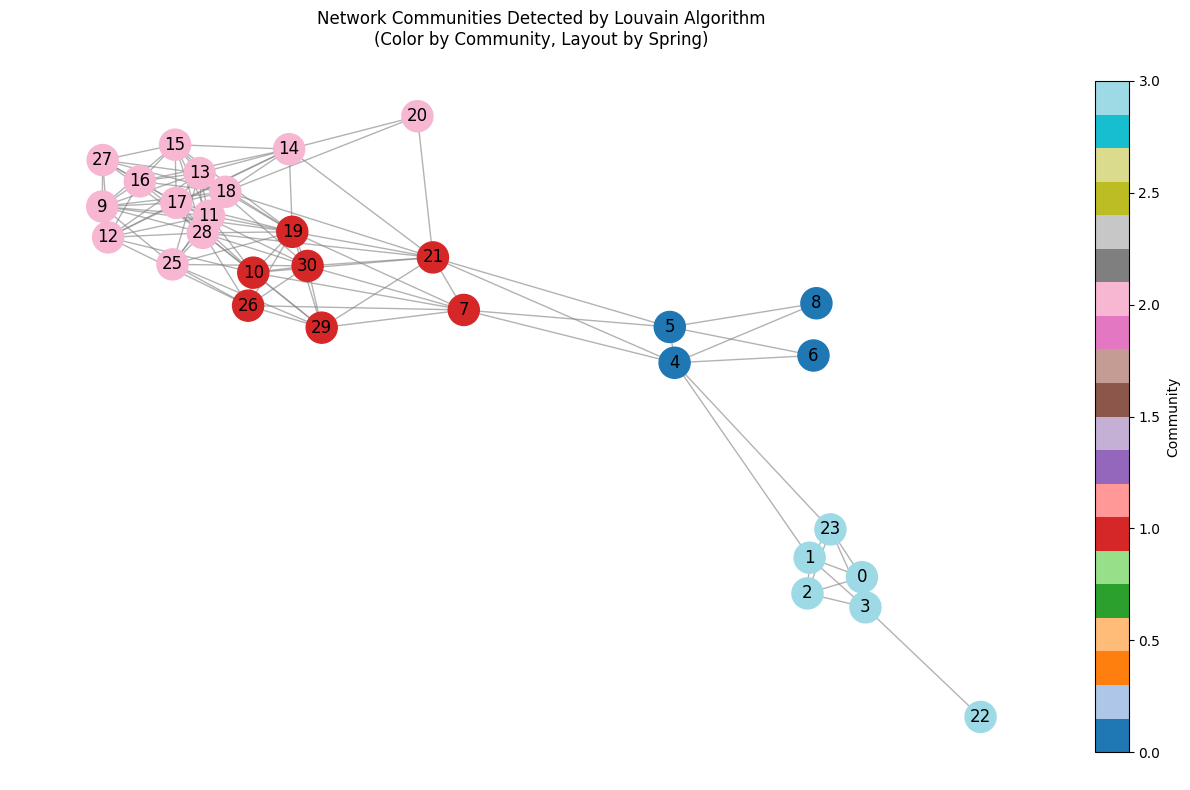

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses2.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 4

Total number of nodes (colleges): 29

Community 0: ['4', '5', '21', '6', '7', '8']
Community 1: ['17', '16', '13', '14', '15', '27', '20']
Community 2: ['28', '10', '11', '18', '19', '30', '25', '26', '9', '12']
Community 3: ['0', '1', '2', '3', '23', '22']

Modularity: 0.4589425472189173
Coverage: 0.7159090909090909
Performance: 0.8571428571428571


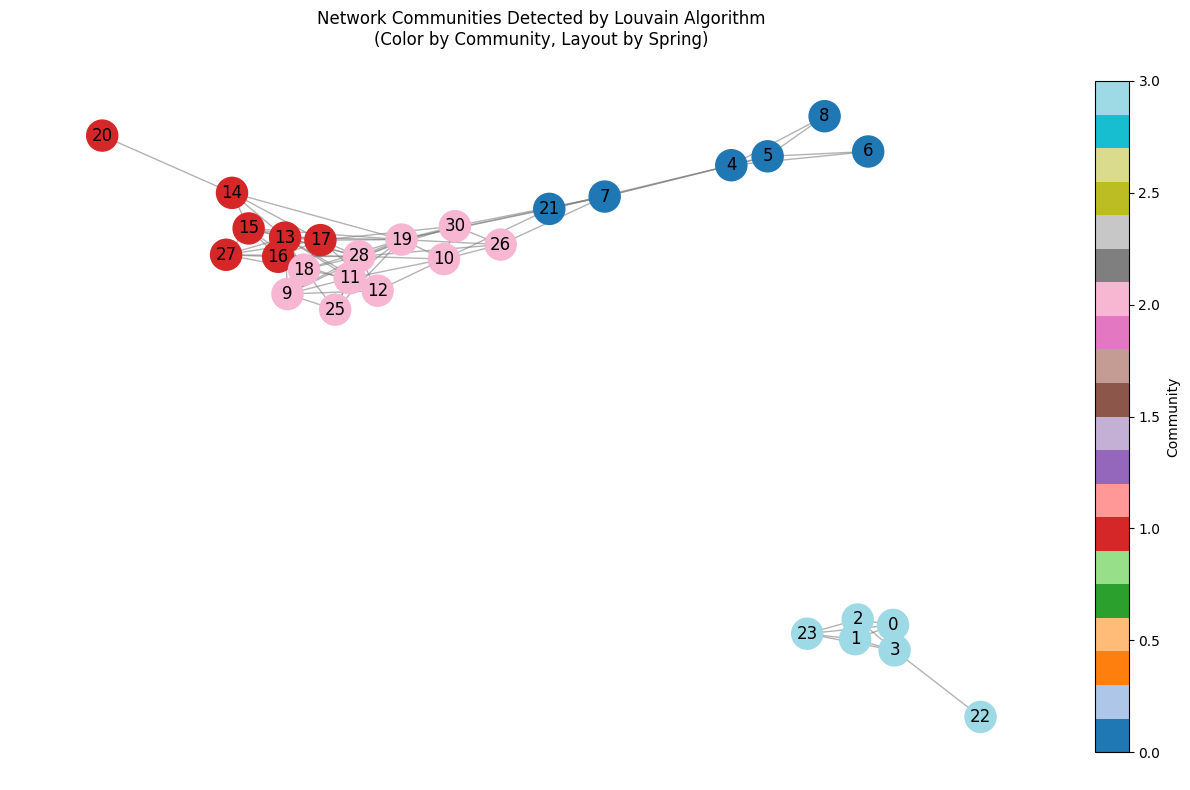

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 3

Total number of nodes (colleges): 29

Community 0: ['4', '5', '21', '6', '7', '8']
Community 1: ['17', '28', '10', '16', '11', '18', '13', '14', '19', '30', '15', '27', '25', '26', '9', '12', '20']
Community 2: ['0', '1', '2', '3', '23', '22']

Modularity: 0.4556300193337298
Coverage: 0.9431818181818182
Performance: 0.7832512315270936


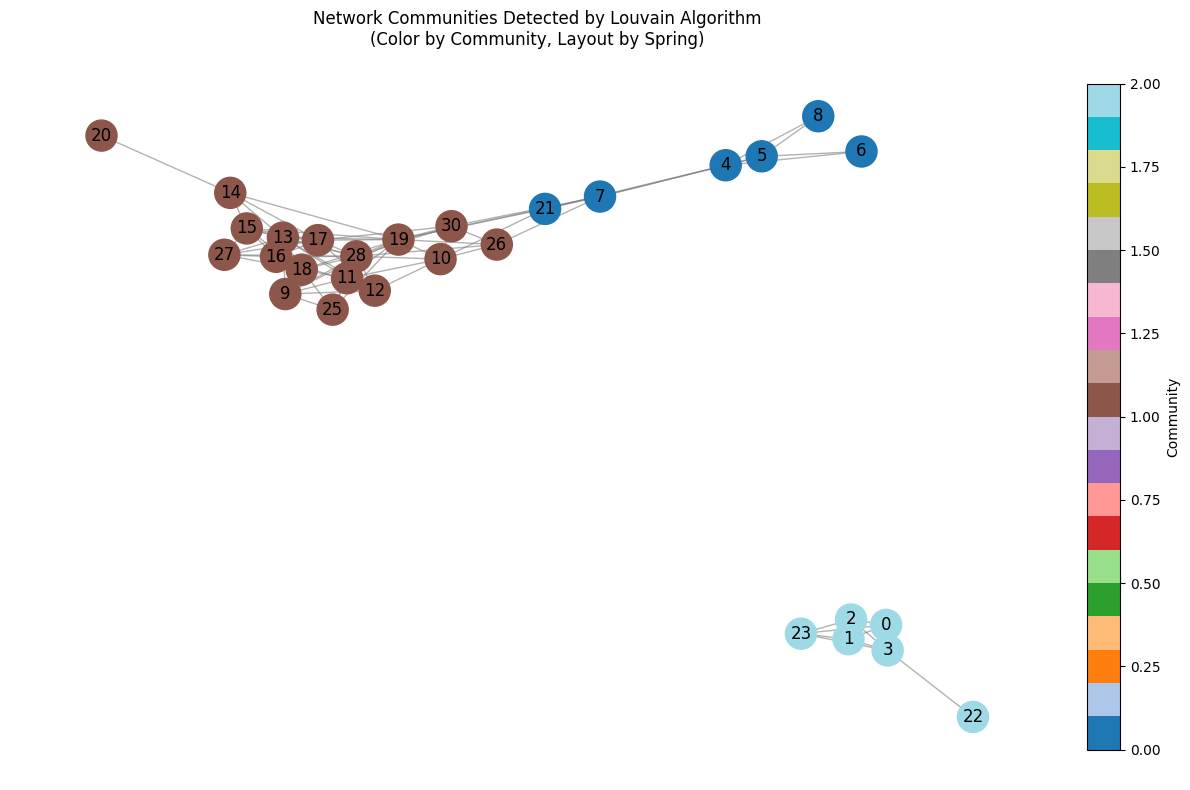

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 4

Total number of nodes (colleges): 28

Community 0: ['4', '5', '21', '6', '7', '8']
Community 1: ['17', '28', '10', '16', '11', '18', '13', '19', '30', '15', '27', '25', '26', '9', '12']
Community 2: ['0', '1', '2', '3', '23']
Community 3: ['14', '20']

Modularity: 0.48451471893996306
Coverage: 0.9577464788732394
Performance: 0.8253968253968254


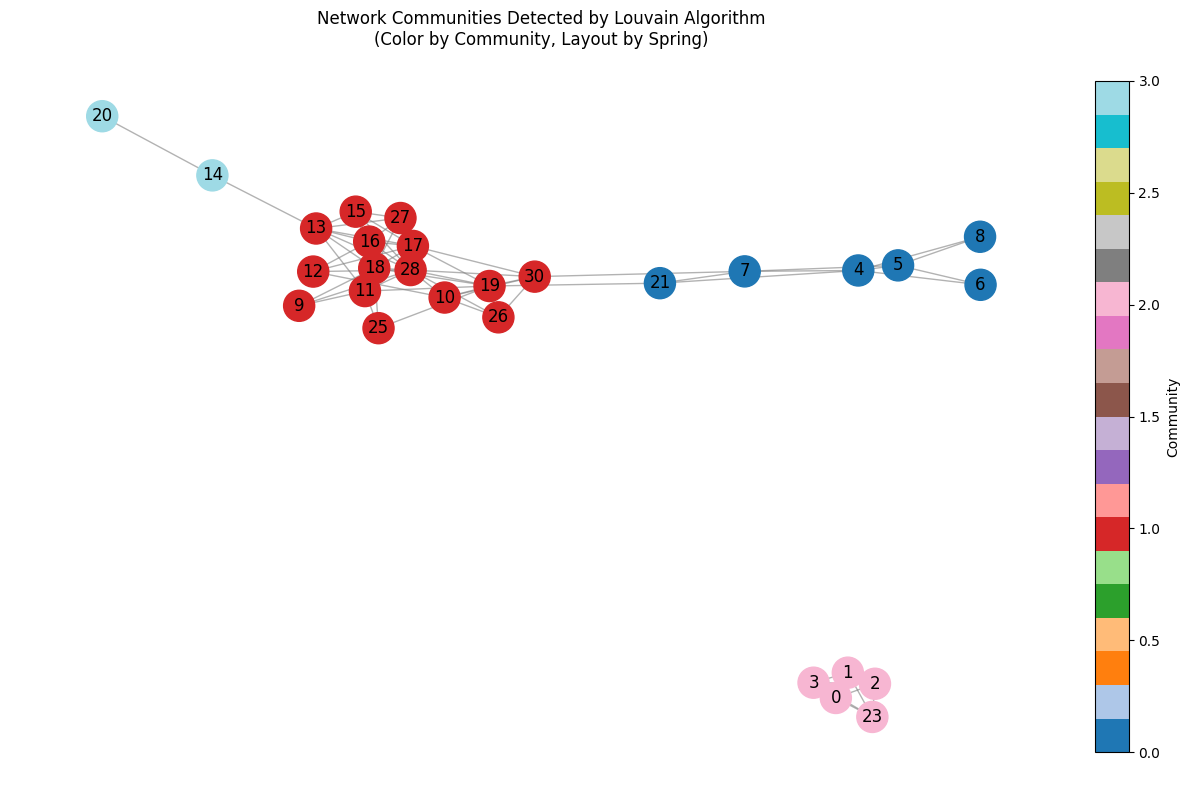

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses4.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 4

Total number of nodes (colleges): 28

Community 0: ['4', '5', '21', '6', '7', '8']
Community 1: ['14', '20']
Community 2: ['0', '1', '2', '3', '23']
Community 3: ['17', '28', '10', '16', '11', '18', '13', '19', '30', '15', '27', '25', '26', '9', '12']

Modularity: 0.48451471893996306
Coverage: 0.9577464788732394
Performance: 0.8253968253968254


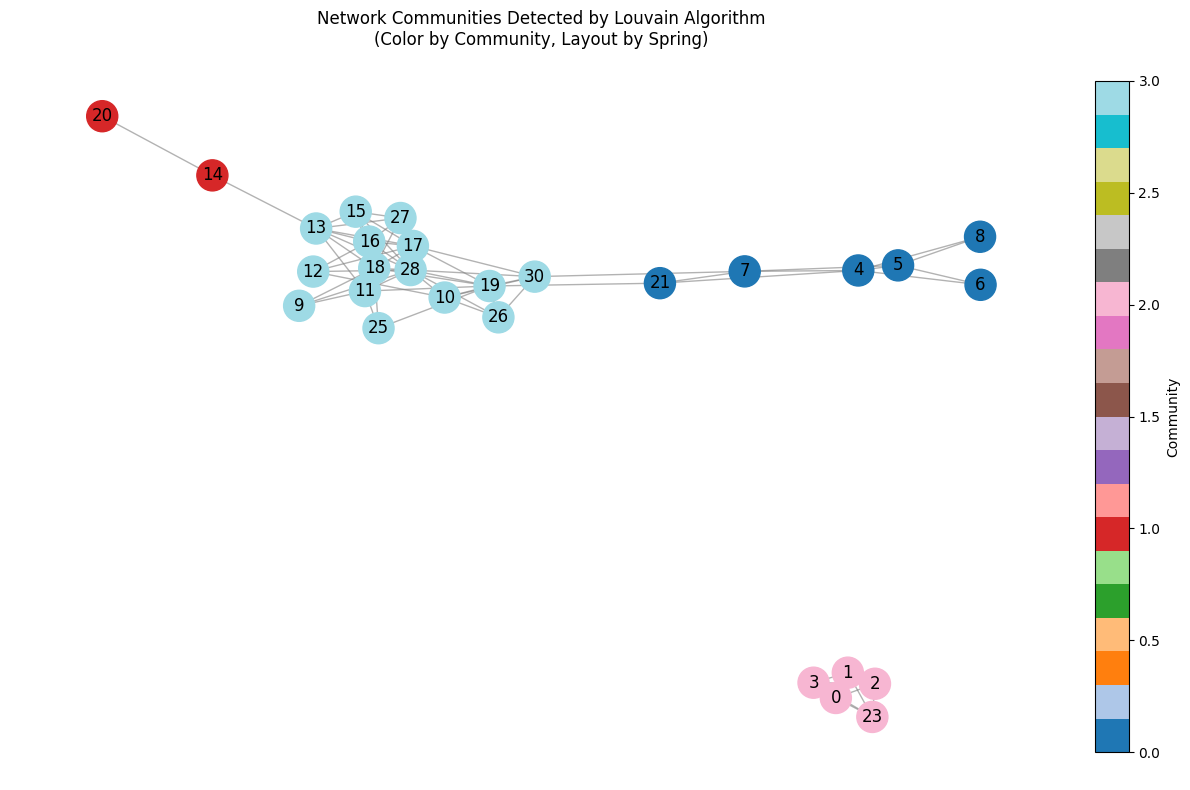

In [21]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses4.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 4

Total number of nodes (colleges): 26

Community 0: ['4', '5', '6']
Community 1: ['17', '16', '18', '13', '14', '15', '27', '25', '9']
Community 2: ['28', '10', '11', '19', '30', '21', '26', '12', '7']
Community 3: ['0', '1', '2', '3', '23']

Modularity: 0.4981913832199546
Coverage: 0.803921568627451
Performance: 0.8338461538461538


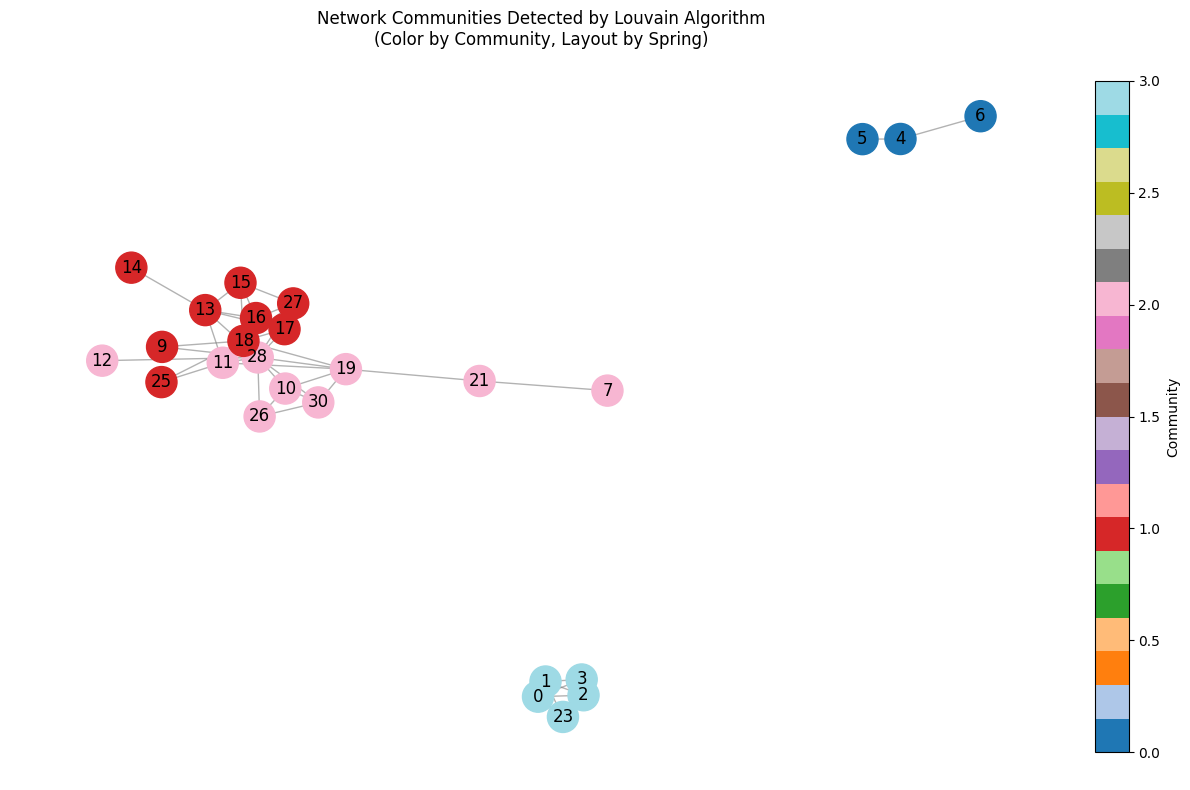

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd

# 安装提示（如未安装）：
# pip install python-louvain

import community as community_louvain  # 这是 python-louvain 库

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses5.txt')
G = G.to_undirected()

# 注意：Louvain 算法可以利用边权重！建议保留权重以获得更合理结果
# 所以我们不再转为无权重图，而是直接使用带权重的 G
# 如果你坚持不用权重，可取消下一行注释并改用 G_unweighted
# G_unweighted = nx.Graph(G)
# 但这里推荐使用带权重的 G

# 计算度中心性（基于无权重图，因为 degree_centrality 忽略权重）
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法进行社区检测 ===
# resolution 参数可选，默认为 1.0；值越大，社区越小
partition = community_louvain.best_partition(G, weight='weight', resolution=1.0)

# partition 是 {node: community_id} 字典
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)
communities = list(communities_dict.values())

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

# === 新增：打印节点总数和各社区成员 ===
total_nodes = G.number_of_nodes()
print(f"\nTotal number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出（partition 中的 ID 可能不连续，但 dict keys 可排序）
sorted_community_ids = sorted(communities_dict.keys())
for comm_id in sorted_community_ids:
    nodes_in_comm = communities_dict[comm_id]
    print(f"Community {comm_id}: {nodes_in_comm}")
print()  # 空行分隔

# 计算模块度（使用 Louvain 自带的函数，或 networkx）
modularity_value = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity: {modularity_value}")

# 构建 community_map 用于后续指标计算和绘图
community_map = partition  # 直接使用 partition 字典

# 手动实现覆盖度（Coverage）
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分（Performance）
def compute_performance(G, communities):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges = set(G.edges())
    
    # 实际存在的内部边
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    # 实际存在的外部边
    inter_edges = len(actual_edges) - intra_edges
    
    # 所有可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    # 所有可能的外部边
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # Performance = (正确预测的边数) / (所有可能的边数)
    # 正确预测 = 实际内部边 + 不存在的外部边（即应无边且确实无边）
    missing_inter_edges = possible_inter_edges - inter_edges  # 应无边且确实无边
    correct_predictions = intra_edges + missing_inter_edges
    
    performance = correct_predictions / total_possible_edges if total_possible_edges > 0 else 0
    return performance

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# 准备绘图数据
nodes = list(G.nodes())
community_colors = [community_map[node] for node in nodes]
centrality_values = [degree_centrality[node] for node in nodes]

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # 固定 seed 使布局可复现

# 绘制节点（按社区着色）
nodes_draw = nx.draw_networkx_nodes(
    G, pos,
    node_color=community_colors,
    cmap=plt.cm.tab20,
    node_size=500
)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=12)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条（社区 ID）
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Network Communities Detected by Louvain Algorithm\n(Color by Community, Layout by Spring)')
plt.gca().set_facecolor('white')
plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

Number of communities: 4
Community 1 (core: 28, centrality=0.5000)
Community 2 (core: 13, centrality=0.3929)
Community 3 (core: 7, centrality=0.2143)
Community 4 (core: 3, centrality=0.1786)


C:\Users\司伟\AppData\Local\Temp\ipykernel_18116\2745294332.py:129: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)


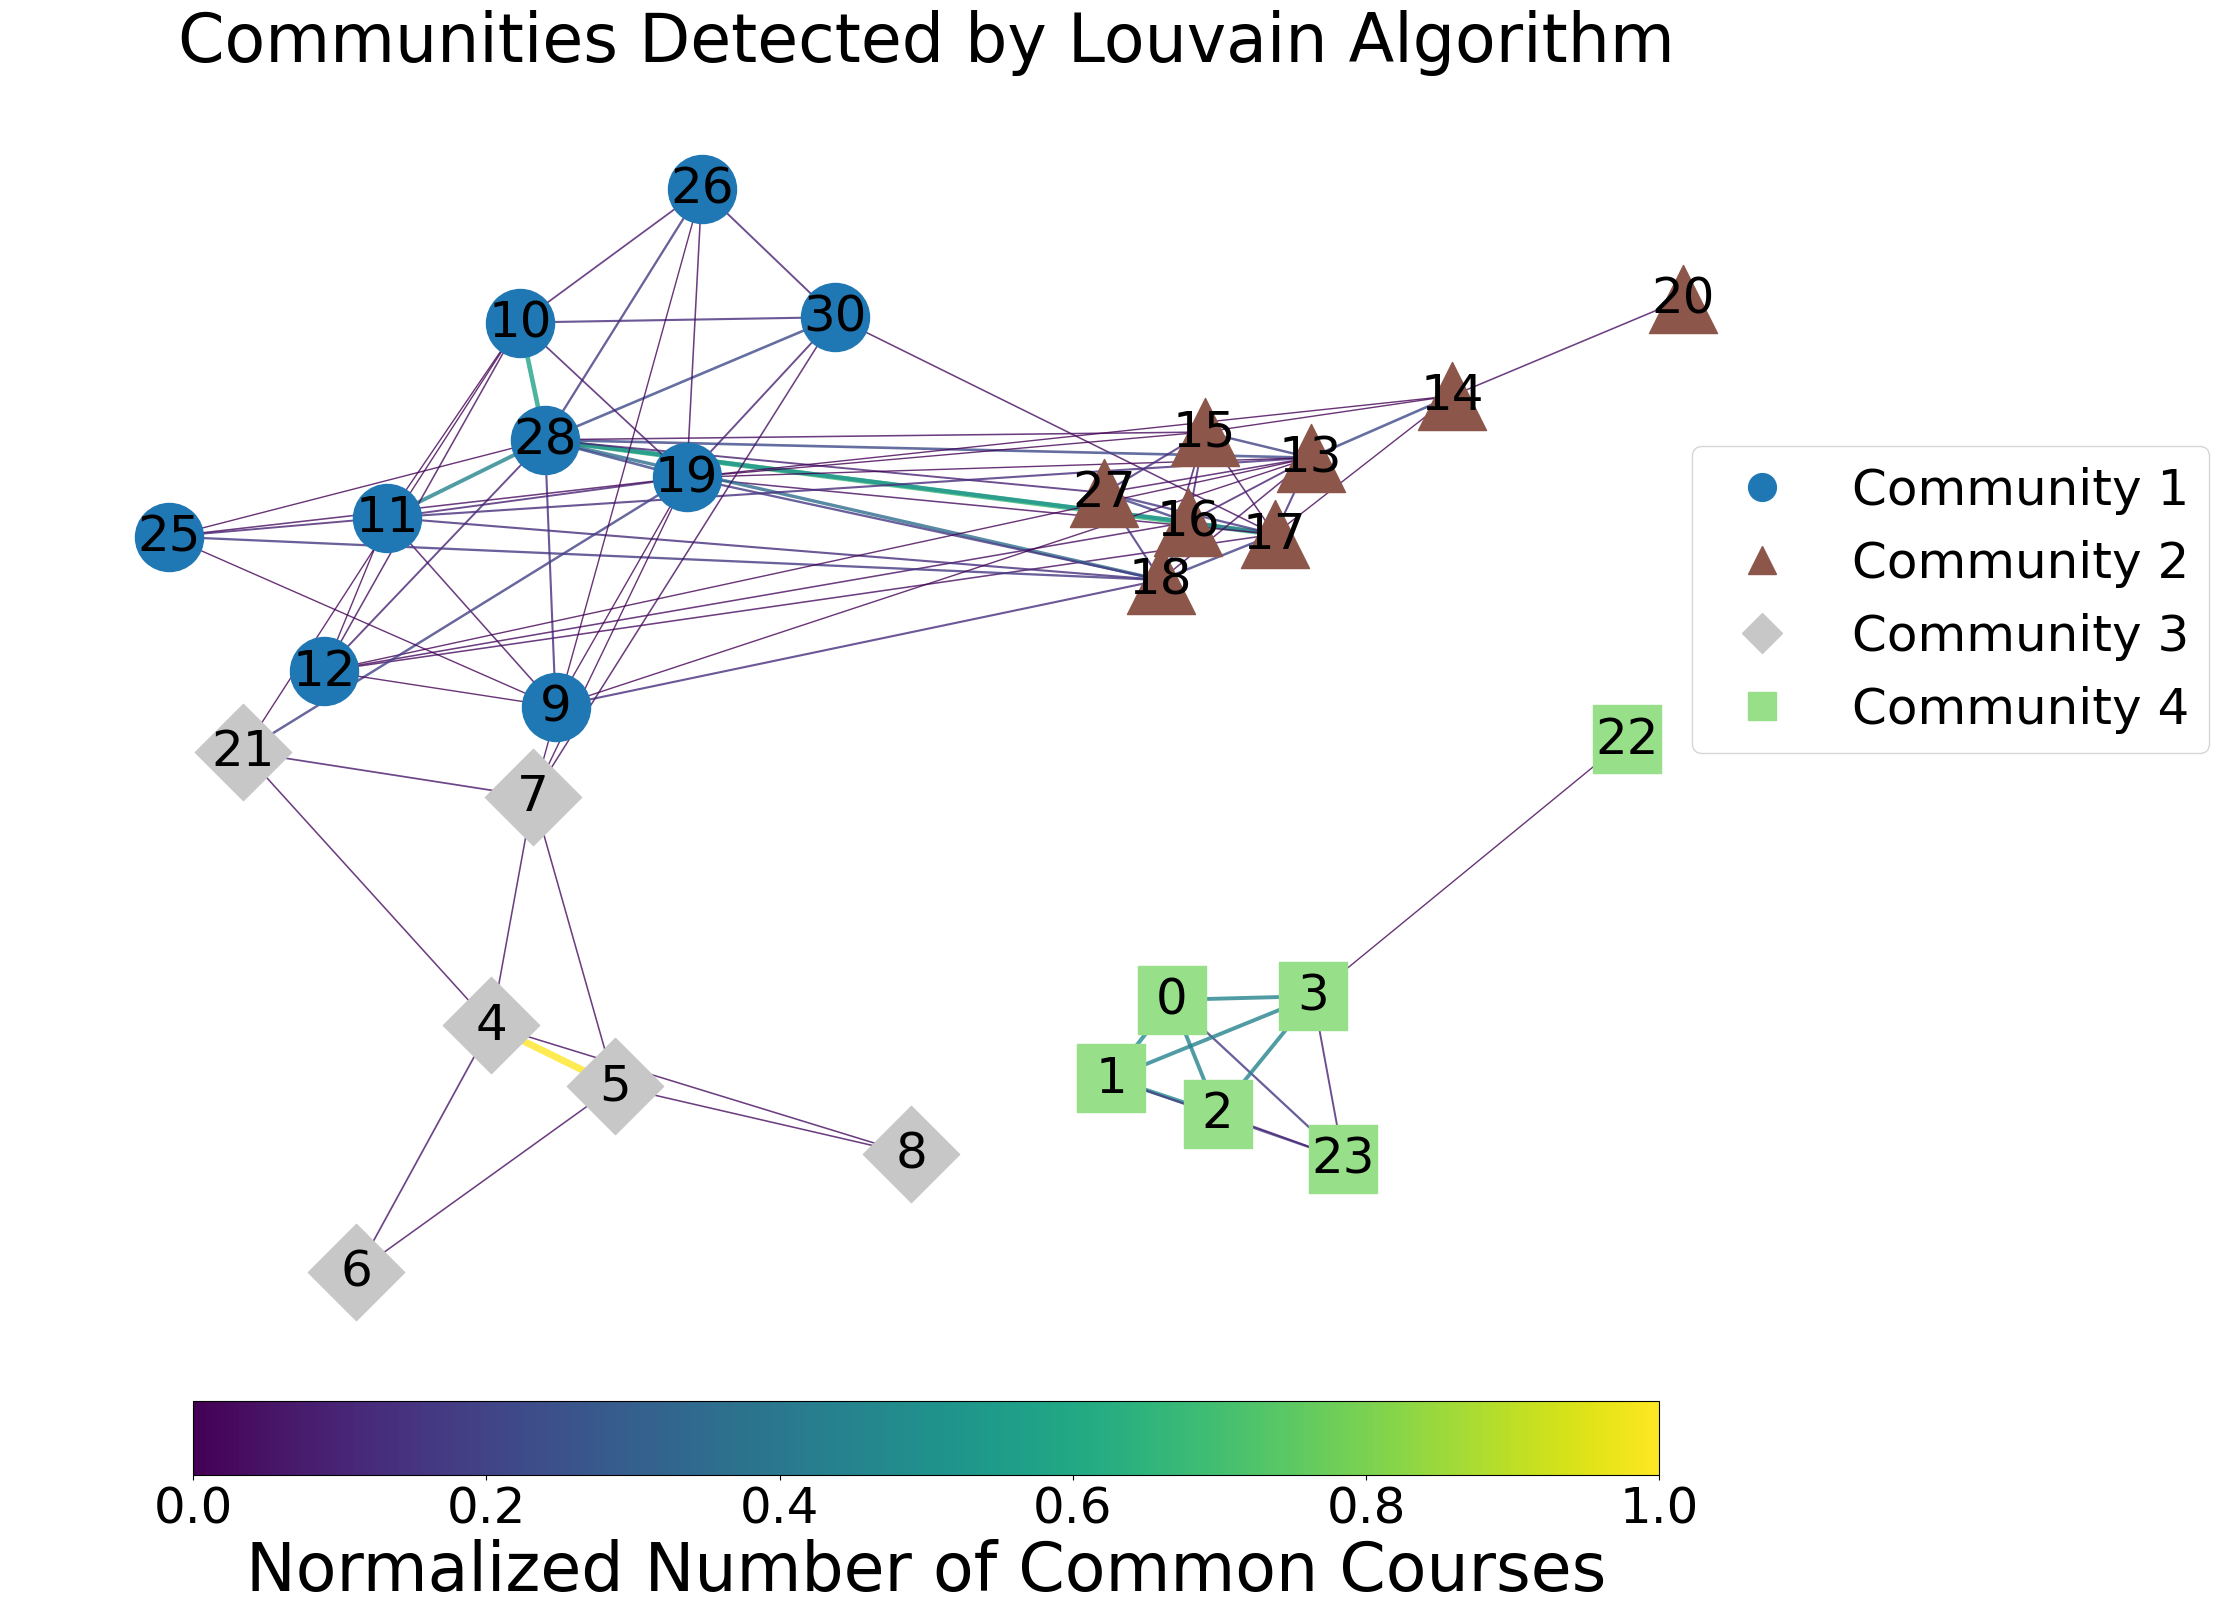

In [109]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable, tab20
import matplotlib.lines as mlines
import community as community_louvain  # python-louvain
import math

# 读取图数据
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 计算度中心性
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法 ===
partition = community_louvain.best_partition(
    G,
    weight='weight',
    resolution=1.0,
   # random_state=42#
)

# 转换为 communities
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)

original_ids = sorted(communities_dict.keys())
original_communities = [communities_dict[cid] for cid in original_ids]

# === 按每个社区的最大度中心性降序排序 ===
def max_centrality_of_community(community):
    return max(degree_centrality[node] for node in community)

sorted_communities = sorted(
    original_communities,
    key=max_centrality_of_community,
    reverse=True
)

# 重建 community_map: node -> new_index (0=Community 1, ...)
community_map = {}
for new_idx, community in enumerate(sorted_communities):
    for node in community:
        community_map[node] = new_idx

communities = sorted_communities
num_communities = len(communities)

# 强制要求 4 个社区（因你要交换 2/3/4）
assert num_communities == 4, f"Expected 4 communities, got {num_communities}"

# 打印排序结果
print(f"Number of communities: {num_communities}")
for i, community in enumerate(communities):
    max_node = max(community, key=lambda n: degree_centrality[n])
    print(f"Community {i+1} (core: {max_node}, centrality={degree_centrality[max_node]:.4f})")

# ========== 基础形状和颜色（按 4 个社区定义）==========
shapes = ['o', 's', '^', 'D']
colors = [tab20(i / 4) for i in range(4)]

# ========== 视觉重映射（作用于已排序的社区索引）==========
visual_mapping = {
    0: 0,  # Community 1 → 保持样式0
    1: 2,  # Community 2 → 使用样式2（原Community 3的 ^ + color）
    2: 3,  # Community 3 → 使用样式3（原Community 4的 D + color）
    3: 1   # Community 4 → 使用样式1（原Community 2的 s + color）
}

# ========== 可视化 ==========
fig, ax = plt.subplots(figsize=(25, 18))

# 布局：每个社区独立子图
pos = {}
grid_size = math.ceil(math.sqrt(num_communities))
gap = 2

for i, community in enumerate(communities):
    row = i // grid_size
    col = i % grid_size
    center_x = col * gap
    center_y = -row * gap

    subgraph = G.subgraph(community)
    sub_pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)
    for node, (x, y) in sub_pos.items():
        pos[node] = (center_x + x, center_y + y)

# 绘制节点（使用视觉映射）
legend_handles = []
for i in range(num_communities):
    nodes_in_community = [n for n in G.nodes() if community_map[n] == i]
    
    # 获取视觉样式索引
    vis_idx = visual_mapping[i]
    shape = shapes[vis_idx]
    color = colors[vis_idx]

    for node in nodes_in_community:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[node],
            node_color=[color],
            node_shape=shape,
            node_size=2400,
            ax=ax
        )

    legend_handles.append(
        mlines.Line2D([], [], color=color, marker=shape, linestyle='None',
                      markersize=20, label=f'Community {i+1}')
    )

# 节点标签
nx.draw_networkx_labels(G, pos, font_size=36, ax=ax)

# 边：按权重着色
weights_attr = nx.get_edge_attributes(G, 'weight')
if weights_attr:
    max_w = max(weights_attr.values())
    min_w = min(weights_attr.values())
    norm_weights = {
        k: (v - min_w) / (max_w - min_w) if max_w != min_w else 0.5
        for k, v in weights_attr.items()
    }
    edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in G.edges()]
    widths = [1 + norm_weights[edge] * 4 for edge in G.edges()]
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)

    sm_edges = ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=1))
    sm_edges.set_array([])
    cbar_edges = plt.colorbar(sm_edges, ax=ax, orientation='horizontal', pad=0.01, shrink=0.8)
    cbar_edges.set_label('Normalized Number of Common Courses', fontsize=48)
    cbar_edges.ax.tick_params(labelsize=36)

# 图例
ax.legend(
    handles=legend_handles,
    title="",
    fontsize=36,
    title_fontsize=28,
    loc='right',
    bbox_to_anchor=(1.20, 0.6),
    borderaxespad=0.
)

ax.set_title('Communities Detected by Louvain Algorithm', fontsize=48)
ax.set_facecolor('white')
ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
plt.savefig("D:/作业合集/数字化市场分析/louvain_sorted_remap.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 1 (max centrality node: 28 = 0.5000):
  Members: ['28', '10', '11', '18', '19', '30', '25', '26', '9', '12']

Community 2 (max centrality node: 13 = 0.3929):
  Members: ['17', '16', '13', '14', '15', '27', '20']

Community 3 (max centrality node: 7 = 0.2143):
  Members: ['4', '5', '21', '6', '7', '8']

Community 4 (max centrality node: 3 = 0.1786):
  Members: ['0', '1', '2', '3', '23', '22']



C:\Users\司伟\AppData\Local\Temp\ipykernel_24292\853445650.py:103: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)
C:\Users\司伟\AppData\Local\Temp\ipykernel_24292\853445650.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.9])


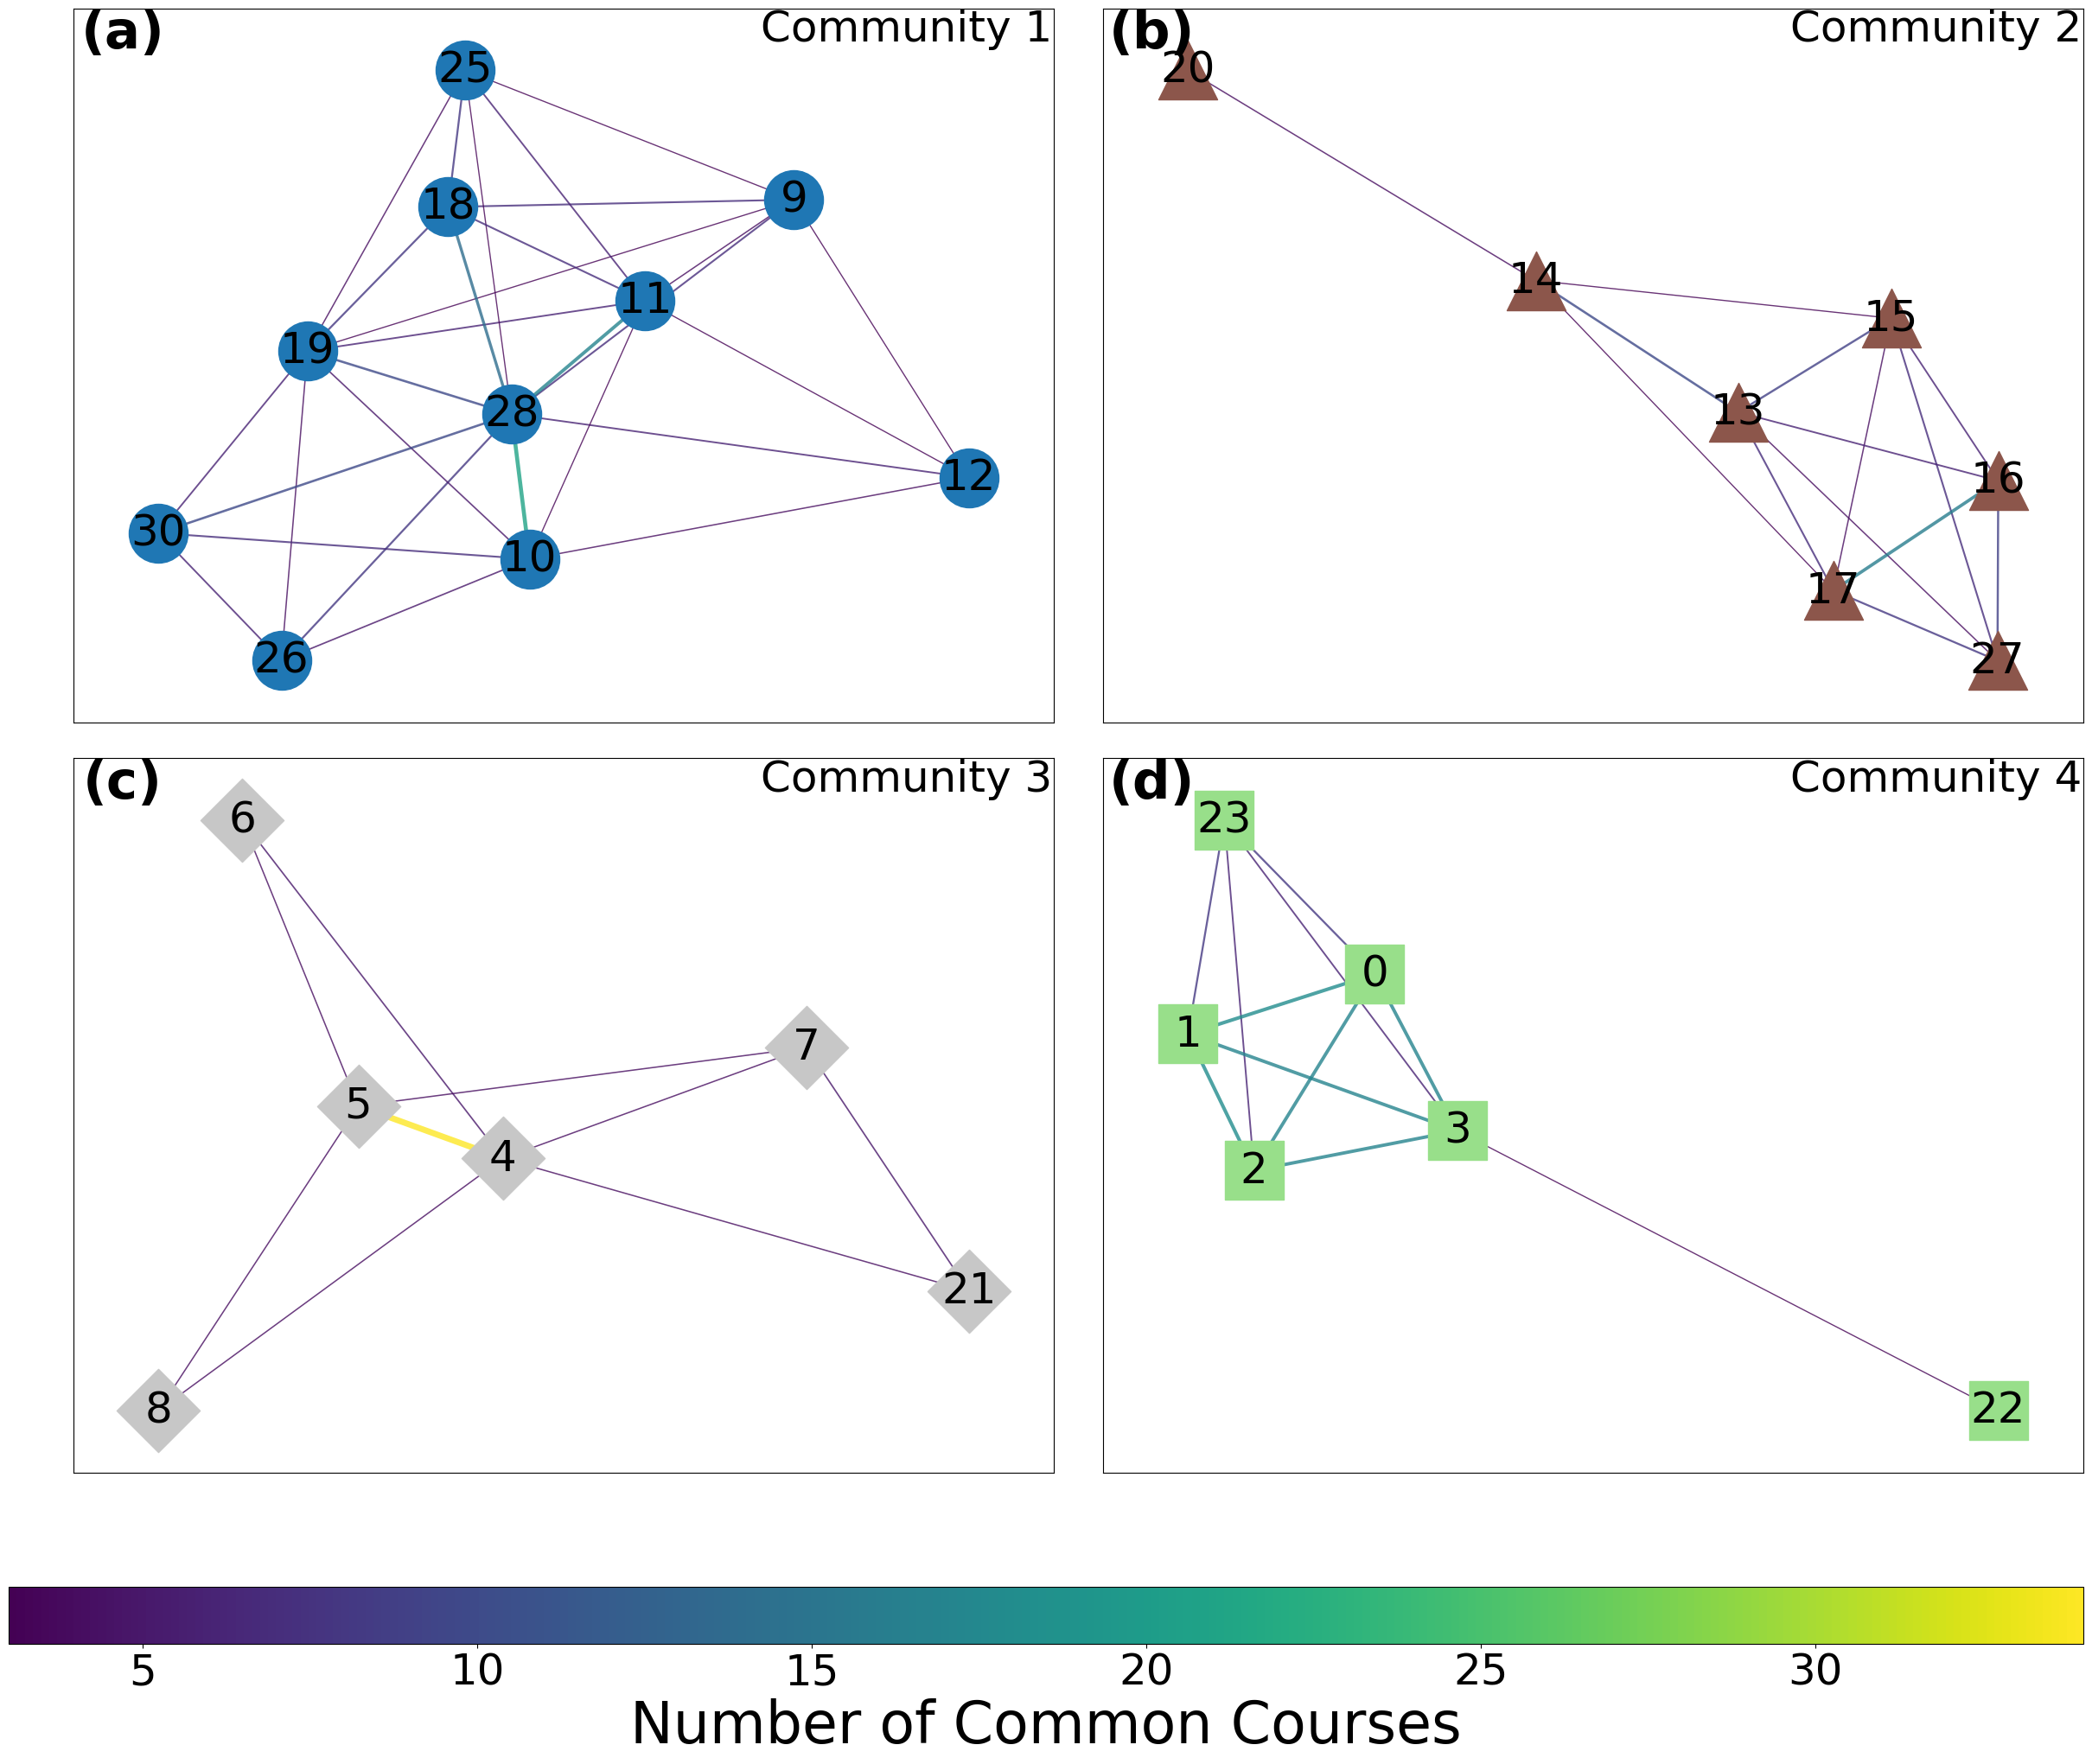

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable, tab20
import community as community_louvain  # python-louvain
import matplotlib.colors as mcolors

# 读取图数据
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 计算度中心性
degree_centrality = nx.degree_centrality(G)

# === 使用 Louvain 算法 ===
partition = community_louvain.best_partition(
    G,
    weight='weight',
    resolution=1.0,
    # random_state=42  # 可选
)

# 转换为 communities
communities_dict = {}
for node, comm_id in partition.items():
    communities_dict.setdefault(comm_id, []).append(node)

original_comm_ids = sorted(communities_dict.keys())
original_communities = [communities_dict[cid] for cid in original_comm_ids]

# 按每个社区的最大度中心性降序排序
def max_centrality_of_community(community):
    return max(degree_centrality[node] for node in community)

sorted_communities = sorted(
    original_communities,
    key=max_centrality_of_community,
    reverse=True
)

# 重建 community_map
community_map = {}
for new_idx, community in enumerate(sorted_communities):
    for node in community:
        community_map[node] = new_idx

communities = sorted_communities
num_communities = len(communities)

# === 强制要求 4 个社区（四宫图前提）===
assert num_communities == 4, f"Expected 4 communities for 2x2 plot, but got {num_communities}. Please check your data or algorithm."

# 打印信息
print(f"Number of communities: {num_communities}")
total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

for i, community in enumerate(communities):
    max_node = max(community, key=lambda n: degree_centrality[n])
    max_cent = degree_centrality[max_node]
    print(f"Community {i+1} (max centrality node: {max_node} = {max_cent:.4f}):")
    print(f"  Members: {list(community)}\n")


# ========== 四宫格可视化 ==========
shapes = ['o', 's', '^', 'D']  # 基础样式库
colors = [tab20(i / 4) for i in range(4)]

# >>> 新增：视觉重映射 <<<
visual_mapping = {
    0: 0,  # Community 1 → 样式0
    1: 2,  # Community 2 → 样式2 (原Community 3)
    2: 3,  # Community 3 → 样式3 (原Community 4)
    3: 1   # Community 4 → 样式1 (原Community 2)
}

# 计算全局边权重范围（用于统一颜色映射）
all_weights = [d['weight'] for u, v, d in G.edges(data=True)]
global_min = min(all_weights)
global_max = max(all_weights)

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(30, 22), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

for idx in range(4):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    community_nodes = communities[idx]
    subgraph = G.subgraph(community_nodes)
    pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)
    
    # 边（不变）
    weights = nx.get_edge_attributes(subgraph, 'weight')
    if weights:
        norm_weights = {
            edge: (w - global_min) / (global_max - global_min)
            for edge, w in weights.items()
        }
        edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in subgraph.edges()]
        widths = [1 + norm_weights[edge] * 4 for edge in subgraph.edges()]
        nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)
    
    # >>> 关键修改：使用视觉映射选择 shape 和 color <<<
    vis_idx = visual_mapping[idx]      # 获取视觉样式索引
    color = colors[vis_idx]
    shape = shapes[vis_idx]
    
    nx.draw_networkx_nodes(
        subgraph, pos,
        node_color=[color],
        node_shape=shape,
        node_size=2400,
        ax=ax
    )
    
    # 标签（不变）
    nx.draw_networkx_labels(subgraph, pos, font_size=36, ax=ax)
    
    # 社区标题（注意：标签仍是 Community 1/2/3/4，不改名）
    ax.text(0.85, 1.0, f'Community {idx+1}',
            transform=ax.transAxes,
            fontsize=36, ha='center', va='top')
    
    ax.text(0.05, 1.0, subplot_labels[idx],
            transform=ax.transAxes,
            fontsize=44, ha='center', va='top', fontweight='bold')

# 颜色条（不变）
sm = ScalarMappable(
    cmap=plt.cm.viridis,
    norm=mcolors.Normalize(vmin=global_min, vmax=global_max)
)
sm.set_array([])
cbar_ax = fig.add_axes([0.1, 0.02, 0.8, 0.03])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Number of Common Courses', fontsize=48)
cbar.ax.tick_params(labelsize=36)

plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.savefig("D:/作业合集/数字化市场分析/louvain_four_panel_remap.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()